# NIH Chest X-ray 14 - High-Level Data Analysis

This notebook performs high-level exploratory analysis of the NIH Chest X-ray dataset downloaded from Kaggle.

## Environment Setup

This cell establishes a reproducible environment. A fixed `RANDOM_STATE = 42` is seeded into both NumPy and Python's `random` module, ensuring that any stochastic operations (shuffling, sampling) produce identical results across runs. Seaborn's `whitegrid` style at 120 DPI gives publication-quality plots. The wide `display.max_columns = 200` setting prevents pandas from hiding columns when the multi-label binary matrix (14+ columns) is rendered inline — an important QoL setting for this dataset.

In [49]:
# Core imports
from pathlib import Path
from collections import Counter
import random
import warnings

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

warnings.filterwarnings("ignore")

# Plot defaults
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],  # Sets the specific font
    'font.size': 17, 
    'axes.labelsize': 17, 
    'axes.titlesize': 20, 
    'legend.fontsize': 17, 
    'xtick.labelsize': 17, 
    'ytick.labelsize': 17
})
plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

## Dataset Download & File Discovery

KaggleHub caches datasets locally after the initial download, so subsequent runs skip the network transfer. The cell discovers all CSV metadata files (useful if the Kaggle package ships multiple splits or auxiliary tables) and indexes every image file into a dictionary. That `image_lookup` dict enables O(1) image retrieval by filename stem later when rendering class samples. If fewer images are found than expected (~112 k for the full NIH dataset), it may indicate the download is partial or the dataset variant only contains a subset.

In [2]:
# Download dataset from KaggleHub
DATASET_HANDLE = "khanfashee/nih-chest-x-ray-14-224x224-resized"
dataset_path = Path(kagglehub.dataset_download(DATASET_HANDLE))

print(f"Dataset downloaded to: {dataset_path}")

# Discover useful files
csv_files = sorted(dataset_path.rglob("*.csv"))
if not csv_files:
    raise FileNotFoundError("No CSV metadata files found in downloaded dataset.")

print(f"Found {len(csv_files)} CSV files:")
for p in csv_files[:10]:
    print(f"- {p.relative_to(dataset_path)}")
if len(csv_files) > 10:
    print(f"... and {len(csv_files) - 10} more")

# Build a quick image index for later visualization
image_paths = []
for pattern in ("*.png", "*.jpg", "*.jpeg"):
    image_paths.extend(dataset_path.rglob(pattern))

image_paths = sorted(set(image_paths))
print(f"Found {len(image_paths):,} image files")

Dataset downloaded to: C:\Users\Nifdi Guliyev\.cache\kagglehub\datasets\khanfashee\nih-chest-x-ray-14-224x224-resized\versions\3
Found 2 CSV files:
- BBox_List_2017_Official_NIH.csv
- Data_Entry_2017.csv
Found 112,120 image files


## Metadata Loading

The heuristic picks the largest CSV file as the primary metadata source — a sensible proxy because the label file covers all images while any auxiliary files (e.g., train/test split lists) are smaller. Printing the raw shape and `head()` lets you immediately verify that the expected columns (image filename, label string, patient ID, age, gender) are present before any transformations. A mismatch in row count vs. the image file count discovered in the previous cell would indicate missing or extra metadata entries worth investigating.

In [3]:
# Load and harmonize metadata schema

def pick_best_metadata_file(paths):
    """Pick the most likely label metadata file by preferring larger CSV files."""
    return sorted(paths, key=lambda p: p.stat().st_size, reverse=True)[0]

meta_file = pick_best_metadata_file(csv_files)
print(f"Using metadata file: {meta_file.relative_to(dataset_path)}")

raw_df = pd.read_csv(meta_file)
print(f"Raw metadata shape: {raw_df.shape}")
raw_df.head()

Using metadata file: Data_Entry_2017.csv
Raw metadata shape: (112120, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,058Y,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,058Y,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,058Y,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,081Y,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,081Y,F,PA,2582,2991,0.143,0.143,NaN


## Column Standardization & Binary Label Encoding

**Column harmonization** uses case-insensitive fuzzy matching so the pipeline works regardless of minor naming differences across dataset versions. Age values encoded as strings like `"058Y"` are parsed to integers, which is a quirk of the original NIH release.

**Multi-hot encoding**: each pipe-separated (`|`) label string (e.g., `"Effusion|Atelectasis"`) is split and one binary column per unique label is created. This one-hot-style encoding is essential for multi-label classification — a single image can be simultaneously positive for multiple pathologies. The printed label set should contain the 14 canonical NIH pathologies plus `"No Finding"` as the 15th class (used when no pathology is detected). Any unexpected labels here (typos, extra categories) would surface immediately and warrant cleanup before modeling.

In [4]:
# Standardize key columns (image, labels, patient, age, gender)

def first_match(columns, candidates):
    colmap = {c.lower(): c for c in columns}
    for c in candidates:
        if c.lower() in colmap:
            return colmap[c.lower()]
    return None

image_col = first_match(raw_df.columns, ["Image Index", "image_index", "image", "filename", "file_name", "path"])
label_col = first_match(raw_df.columns, ["Finding Labels", "finding_labels", "labels", "label", "class"])
patient_col = first_match(raw_df.columns, ["Patient ID", "patient_id", "patientid", "subject_id"])
age_col = first_match(raw_df.columns, ["Patient Age", "patient_age", "age"])
gender_col = first_match(raw_df.columns, ["Patient Gender", "patient_gender", "gender", "sex"])

if image_col is None or label_col is None:
    raise ValueError(f"Could not identify image/label columns. Columns found: {list(raw_df.columns)}")

df = raw_df.copy()
df = df.rename(columns={
    image_col: "image_id",
    label_col: "labels_raw",
})
if patient_col:
    df = df.rename(columns={patient_col: "patient_id"})
if age_col:
    df = df.rename(columns={age_col: "age"})
if gender_col:
    df = df.rename(columns={gender_col: "gender"})

# NIH age values are often encoded like '058Y'; extract numeric age.
if "age" in df.columns:
    df["age"] = pd.to_numeric(df["age"].astype(str).str.extract(r"(\d+)", expand=False), errors="coerce")

# Normalize label text and split multi-label entries
df["labels_raw"] = df["labels_raw"].astype(str).str.strip()
df["label_list"] = (
    df["labels_raw"]
    .str.replace("|", ",", regex=False)
    .str.split(",")
    .apply(lambda x: [i.strip() for i in x if i.strip()])
)

all_labels = sorted({label for labels in df["label_list"] for label in labels})
for label in all_labels:
    df[f"label__{label}"] = df["label_list"].apply(lambda labels: int(label in labels))

print(f"Rows: {len(df):,}")
print(f"Unique labels: {len(all_labels)}")
print("Label set:", all_labels)

df.head()

Rows: 112,120
Unique labels: 15
Label set: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


,image_id,labels_raw,Follow-up #,patient_id,age,gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,label_list,label__Atelectasis,label__Cardiomegaly,label__Consolidation,label__Edema,label__Effusion,label__Emphysema,label__Fibrosis,label__Hernia,label__Infiltration,label__Mass,label__No Finding,label__Nodule,label__Pleural_Thickening,label__Pneumonia,label__Pneumothorax
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN,[Cardiomegaly],0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN,"[Cardiomegaly, Emphysema]",0,1,0,0,0,1,0,0,0,0,0,0,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN,"[Cardiomegaly, Effusion]",0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN,[No Finding],0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN,[Hernia],0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


## Quantitative Dataset Profile

This summary table provides a concise, single-glance health check of the dataset:

| Metric | What to look for |
|---|---|
| `num_rows` vs `num_unique_images` | Near-equal values confirm no duplicate metadata rows. |
| `mean_labels_per_image` | The NIH dataset averages ~1.2 labels/image, reflecting that most patients have one finding. Values much higher could indicate labeling errors. |
| `normal_or_no_finding_rate` | Typically ~53 % — the dataset is heavily skewed toward healthy scans. This directly motivates class weighting or oversampling when training. |
| `age_mean / age_std` | The NIH cohort center is around age 46 ± 17. Significant deviation may indicate the Kaggle variant was filtered. |
| `gender_counts` | The original release is ~56 % male / 44 % female — mild but measurable skew worth tracking for fairness audits. |

A `"No Finding"` rate above 50 % is the most consequential observation here: any model trained without rebalancing will default toward predicting the negative class and will appear to have high accuracy while providing no clinical utility.

In [12]:
# Quantitative dataset profile
label_cols = [c for c in df.columns if c.startswith("label__")]

summary = {
    "num_rows": len(df),
    "num_unique_images": df["image_id"].nunique(),
    "num_unique_labels": len(label_cols),
    "mean_labels_per_image": df[label_cols].sum(axis=1).mean(),
    "median_labels_per_image": df[label_cols].sum(axis=1).median(),
    "normal_or_no_finding_rate": (df["labels_raw"].str.lower().str.contains("no finding").mean() * 100),
}

if "patient_id" in df.columns:
    summary["num_unique_patients"] = df["patient_id"].nunique()

if "age" in df.columns:
    age_series = pd.to_numeric(df["age"], errors="coerce")
    summary["age_mean"] = age_series.mean()
    summary["age_std"] = age_series.std()

if "gender" in df.columns and "patient_id" in df.columns:
    # Get unique patient-gender pairs to avoid overcounting multi-image patients
    unique_patients = df.drop_duplicates(subset=["patient_id"])
    summary["gender_counts"] = unique_patients["gender"].value_counts(dropna=False).to_dict()

summary_df = pd.DataFrame([summary]).T.rename(columns={0: "value"})
summary_df

,value
num_rows,112120
num_unique_images,112120
num_unique_labels,15
mean_labels_per_image,1.261149
median_labels_per_image,1.0
normal_or_no_finding_rate,53.881555
num_unique_patients,30805
age_mean,46.901463
age_std,16.839923
gender_counts,"{'M': 16630, 'F': 14175}"


## Label Prevalence & Multi-label Density

**Top-ranked labels** in the NIH dataset are typically `Infiltration`, `Effusion`, `Atelectasis`, and `Nodule` (each present in several thousand images), while `Hernia` and `Pneumonia` are the rarest, appearing in under 1 % of scans.

**Label cardinality** (average number of active labels per image) of ~1.2 means the vast majority of images have exactly one pathology or no finding, but a notable minority carry two or more co-occurring conditions — a key challenge for multi-label learning that single-label classifiers cannot capture.

**Label density** (cardinality ÷ number of classes) of ~0.08 confirms extreme sparsity in the label space: on average, only 8 % of the possible pathologies are active for any given image. Sparse labels push models toward predicting zero/negative, reinforcing the need for per-class loss weighting (e.g., focal loss) or threshold tuning at inference time.

In [13]:
# Label prevalence and multi-label burden
label_prevalence = (
    df[label_cols]
    .sum()
    .sort_values(ascending=False)
    .rename(lambda x: x.replace("label__", ""))
    .to_frame("count")
)
label_prevalence["prevalence_pct"] = 100 * label_prevalence["count"] / len(df)

cardinality = df[label_cols].sum(axis=1)
density = cardinality.mean() / len(label_cols)

print(f"Label cardinality (avg labels/image): {cardinality.mean():.3f}")
print(f"Label density (fraction of active labels): {density:.4f}")
print(f"Max labels in one image: {int(cardinality.max())}")

label_prevalence.head(20)

Label cardinality (avg labels/image): 1.261
Label density (fraction of active labels): 0.0841
Max labels in one image: 9


,count,prevalence_pct
No Finding,60412,53.881555
Infiltration,19870,17.722083
Effusion,13307,11.868534
Atelectasis,11535,10.288084
Nodule,6323,5.639493
Mass,5746,5.124866
Pneumothorax,5298,4.725294
Consolidation,4667,4.162504
Pleural_Thickening,3385,3.019087
Cardiomegaly,2772,2.472351


## Distribution Visualizations

**Left — Top Label Counts (excluding "No Finding"):** The horizontal bar chart reveals a long-tail distribution of pathologies. The gap between the top 2–3 labels and the bottom labels often spans an order of magnitude, confirming that even the "minority" classes among pathologies are severely underrepresented. This extreme imbalance directly informs the need for class-weighted losses (e.g., inverse-frequency weighting or focal loss) rather than standard cross-entropy during training.

**Right — Labels Per Image Distribution:** The histogram is heavily right-skewed with a mode at 1 label. A small fraction of images carry 3 or more simultaneous findings — these are the hardest cases and are statistically unlikely to appear in a randomly sampled validation batch, so fixed train/val/test splits should be stratified by label combination to ensure all rare co-occurring patterns are represented.

**Age Distribution (if shown):** A bell-shaped or slightly right-skewed distribution centered in middle age is expected for a hospital population. Very young patients (under 10) and very old patients (over 90) are outliers in this dataset and may represent labeling artifacts or unusual clinical cases. The IQR filter removes these before plotting for readability.

**Gender Distribution (if shown):** A roughly 56/44 M/F split is characteristic of the NIH release. This minor imbalance is generally not enough to require stratified sampling by gender but should be reported in any publication or fairness analysis of model predictions across demographic groups.

In [23]:
label_prevalence

,count,prevalence_pct
No Finding,60412,53.881555
Infiltration,19870,17.722083
Effusion,13307,11.868534
Atelectasis,11535,10.288084
Nodule,6323,5.639493
Mass,5746,5.124866
Pneumothorax,5298,4.725294
Consolidation,4667,4.162504
Pleural_Thickening,3385,3.019087
Cardiomegaly,2772,2.472351


In [25]:
label_cols

['label__Atelectasis',
 'label__Cardiomegaly',
 'label__Consolidation',
 'label__Edema',
 'label__Effusion',
 'label__Emphysema',
 'label__Fibrosis',
 'label__Hernia',
 'label__Infiltration',
 'label__Mass',
 'label__No Finding',
 'label__Nodule',
 'label__Pleural_Thickening',
 'label__Pneumonia',
 'label__Pneumothorax']

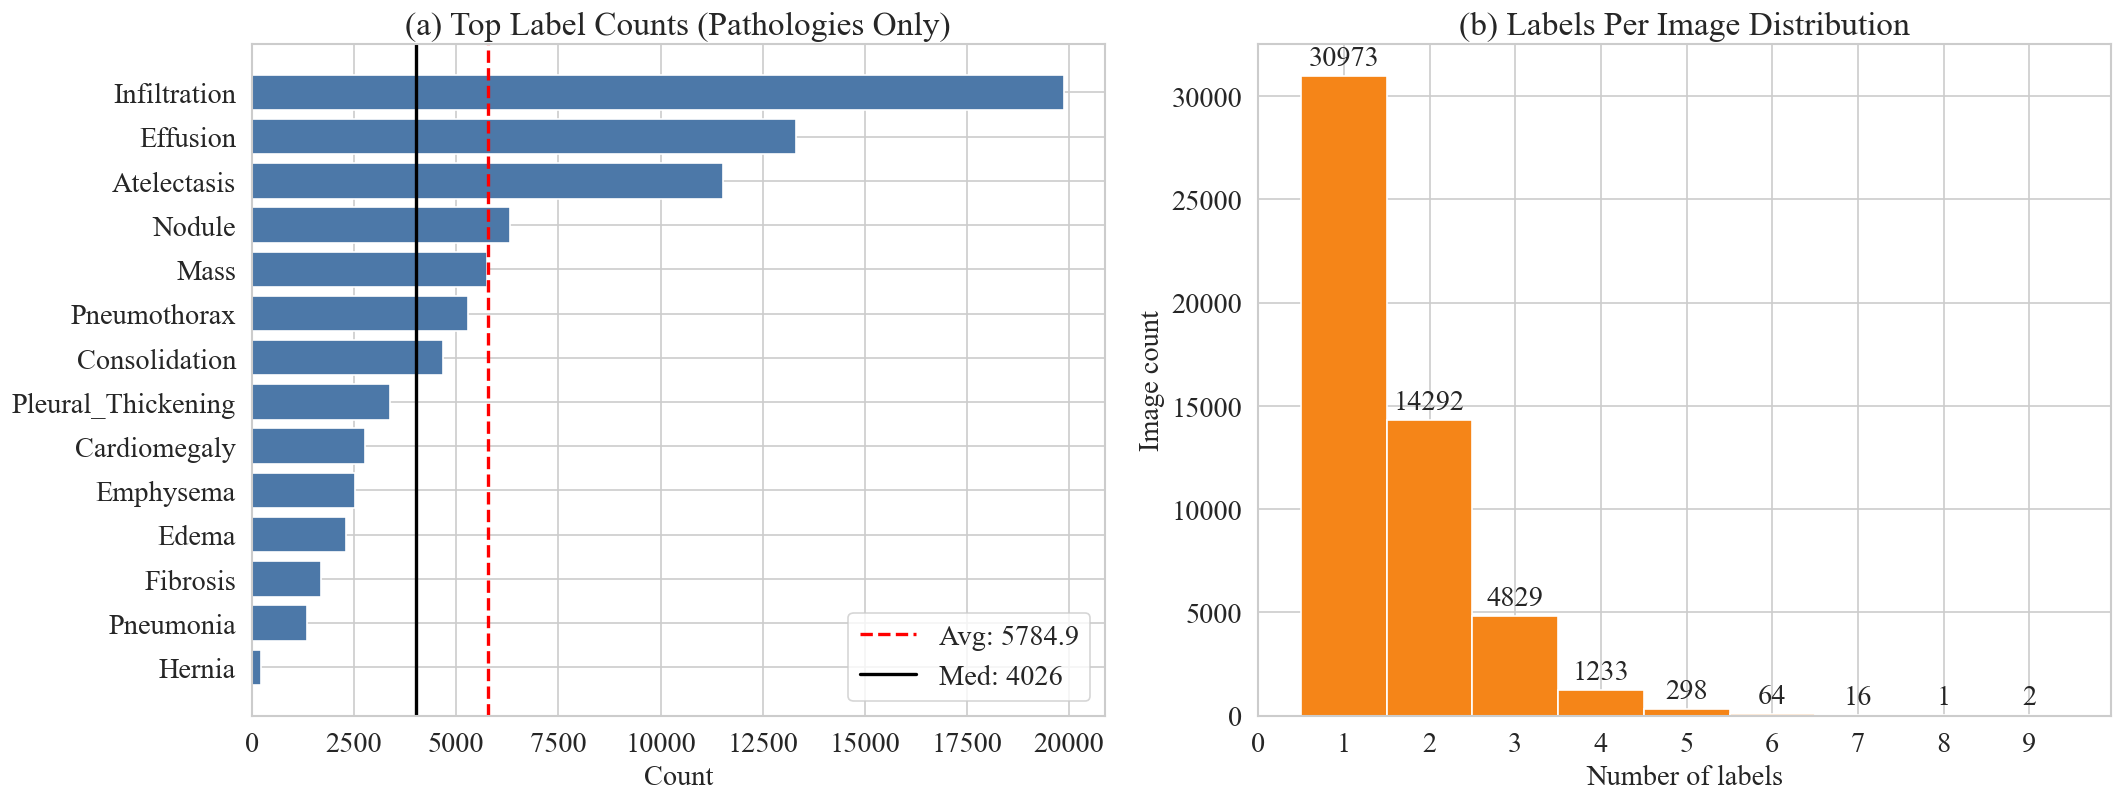

In [48]:
# Label prevalence calculation (already excludes "No Finding")
label_prevalence = (
    df[label_cols]
    .sum()
    .sort_values(ascending=False)
    .rename(lambda x: x.replace("label__", ""))
    .to_frame("count")
)
label_prevalence = label_prevalence[label_prevalence.index.str.lower() != "no finding"]

# Stats for Plot A
avg_val = label_prevalence["count"].mean()
med_val = label_prevalence["count"].median()

# Pathologies only for cardinality
pathology_cols = [c for c in label_cols if "no finding" not in c.lower()]
cardinality = df[pathology_cols].sum(axis=1)

# Create Subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# (A) Top Label Counts
plot_df = label_prevalence.head(15).iloc[::-1]
axes[0].barh(plot_df.index, plot_df["count"], color="#4C78A8")

# Add Vertical lines for Mean and Median
axes[0].axvline(avg_val, color='red', linestyle='--', linewidth=2, label=f'Avg: {avg_val:.1f}')
axes[0].axvline(med_val, color='black', linestyle='-', linewidth=2, label=f'Med: {med_val:.0f}')

axes[0].set_title("(a) Top Label Counts (Pathologies Only)", fontsize=20)
axes[0].set_xlabel("Count")
axes[0].legend(loc='lower right')

# (B) Multi-label cardinality
bins = np.arange(cardinality.min()+1, cardinality.max() + 2) - 0.5
counts, edges, patches = axes[1].hist(
    cardinality, 
    bins=bins, 
    color="#F58518", 
    edgecolor="white"
)

# Add counts on top of each bar
axes[1].bar_label(patches, padding=3)

axes[1].set_title("(b) Labels Per Image Distribution", fontsize=20)
axes[1].set_xlabel("Number of labels")
axes[1].set_ylabel("Image count")
axes[1].set_xticks(np.arange(cardinality.min(), cardinality.max() + 1))

plt.tight_layout()
plt.show()

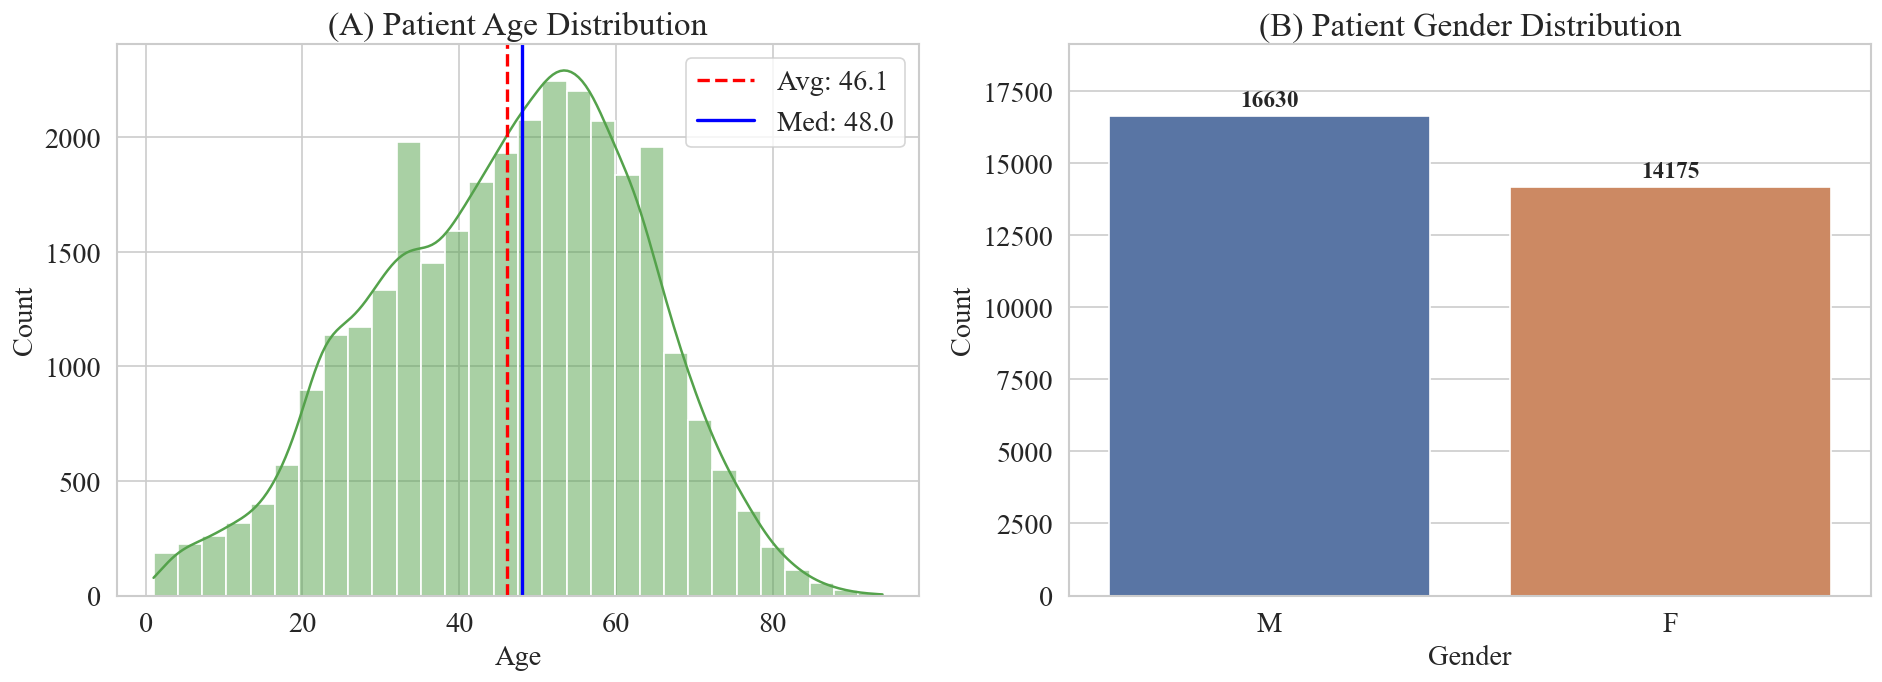

In [57]:
# Create a unique patient slice for demographic plotting
if "patient_id" in df.columns:
    df_unique_patients = df.drop_duplicates(subset=["patient_id"])
else:
    df_unique_patients = df

# Distribution visualizations (Patient-level)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (A) Age Distribution (Unique Patients)
if "age" in df_unique_patients.columns:
    age_vals = pd.to_numeric(df_unique_patients["age"], errors="coerce").dropna()
    
    # Remove age outliers with IQR rule
    q1, q3 = age_vals.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    age_vals_filtered = age_vals[(age_vals >= lower) & (age_vals <= upper)]

    # Plot histogram
    sns.histplot(age_vals_filtered, bins=30, kde=True, color="#54A24B", ax=axes[0])
    
    # Calculate Mean and Median
    avg_age = age_vals_filtered.mean()
    med_age = age_vals_filtered.median()

    # Add vertical lines for Average and Median
    axes[0].axvline(avg_age, color='red', linestyle='--', linewidth=2, label=f'Avg: {avg_age:.1f}')
    axes[0].axvline(med_age, color='blue', linestyle='-', linewidth=2, label=f'Med: {med_age:.1f}')
    
    axes[0].set_title("(A) Patient Age Distribution")
    axes[0].set_xlabel("Age")
    axes[0].set_ylabel("Count")
    axes[0].legend() # Show the labels for mean/median

# (B) Gender Distribution (Unique Patients)
if "gender" in df_unique_patients.columns:
    order = df_unique_patients["gender"].value_counts().index
    ax2 = sns.countplot(data=df_unique_patients, x="gender", order=order, palette="deep", ax=axes[1])
    
    # Add values on top of the bars
    for p in ax2.patches:
        ax2.annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), 
                     textcoords = 'offset points',
                     fontsize=14,
                     fontweight='bold')

    axes[1].set_title("(B) Patient Gender Distribution")
    axes[1].set_xlabel("Gender")
    axes[1].set_ylabel("Count")
    # Add some padding to the top of the y-axis to accommodate labels
    axes[1].set_ylim(0, df_unique_patients["gender"].value_counts().max() * 1.15)

plt.tight_layout()
plt.show()

## Representative Class Samples

Displaying one real X-ray per high-prevalence class serves as a qualitative sanity check:

- **Visual quality**: The 224×224 resized images should appear recognizable as chest X-rays. Significant compression artifacts, watermarks, or blank images would indicate a problem with the download or the image lookup logic.
- **Subtle inter-class differences**: Many NIH pathologies are radiologically subtle or visually overlapping (e.g., Infiltration vs. Consolidation), which is precisely why deep models outperform human experts at scale. The grid makes this challenge intuitive.
- **"No image found" tiles**: If any class displays the fallback text, it means the `image_lookup` dictionary could not resolve the `image_id` for any of the 50 candidates sampled. This typically happens if images are stored in a nested subdirectory structure not captured by the filename stem — a debugging signal rather than a data quality issue.

This visualization is most useful when sharing the notebook with stakeholders unfamiliar with the dataset, anchoring statistical insights to actual clinical imagery.

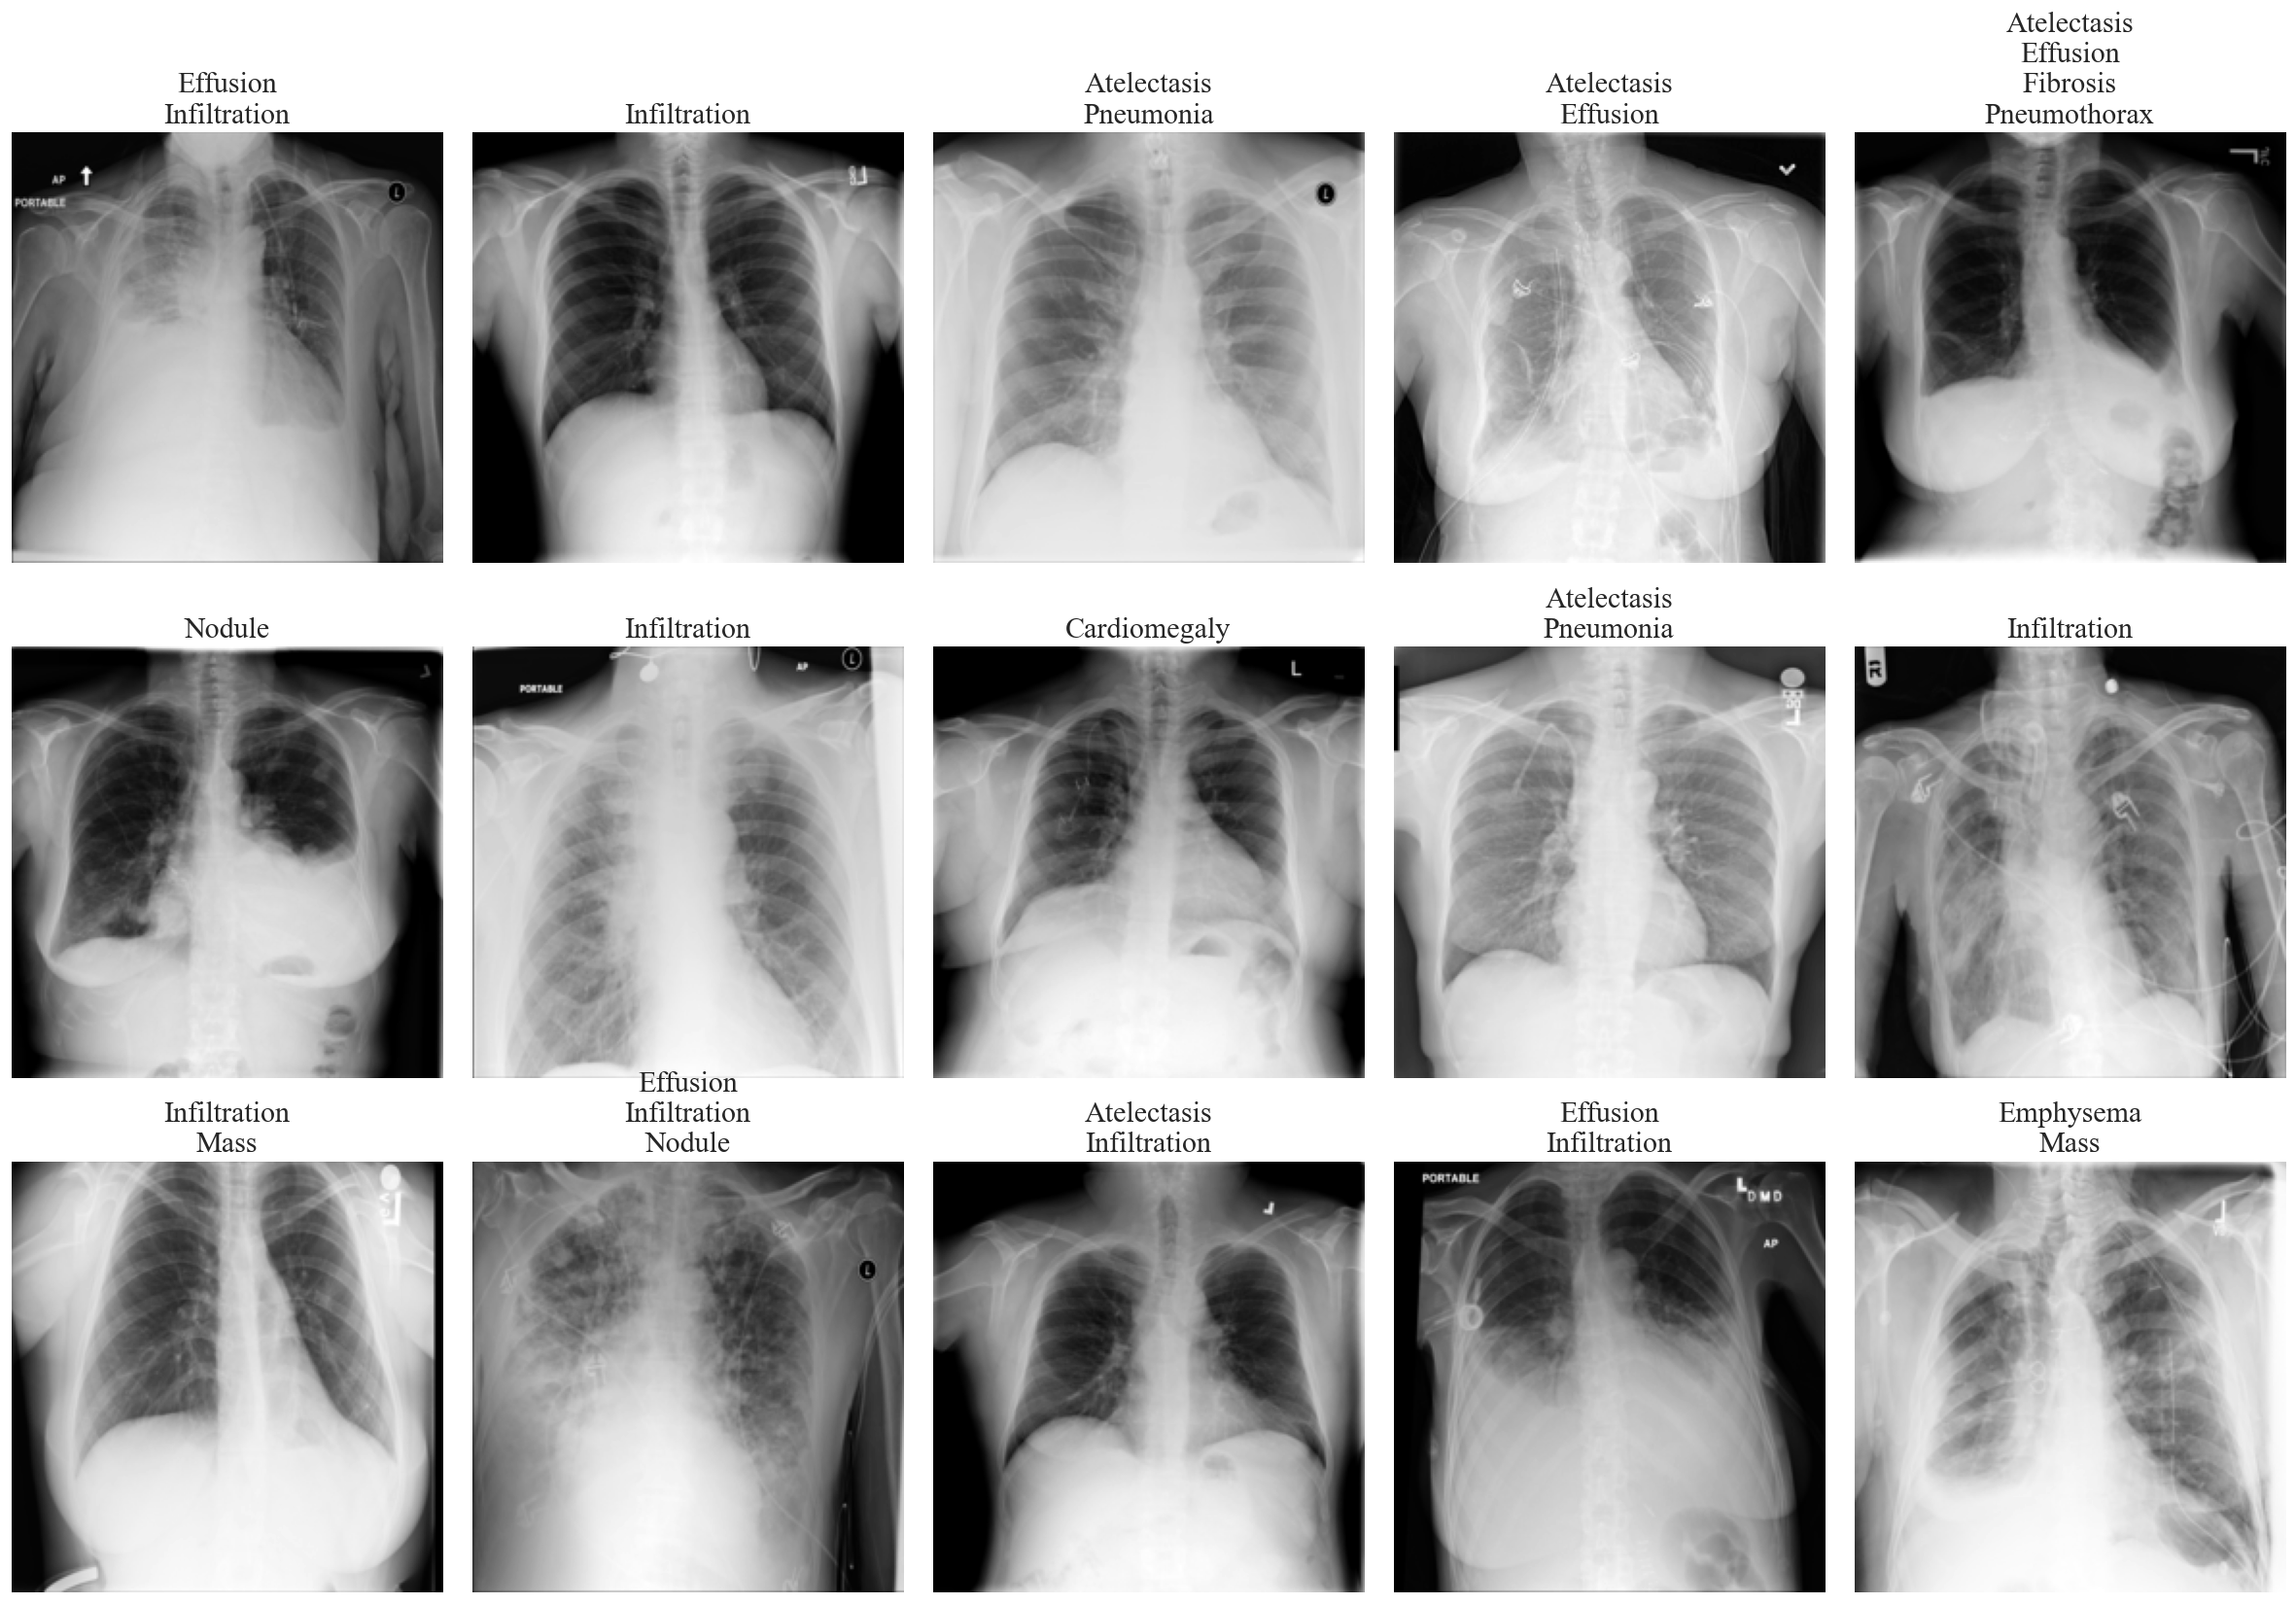

In [92]:
def show_15_pathology_samples():
    # 1. Identify pathology columns (excluding 'No Finding')
    all_label_cols = [c for c in df.columns if c.startswith("label__")]
    pathology_cols = [c for c in all_label_cols if "No Finding" not in c]
    
    # 2. Filter for rows where AT LEAST ONE pathology is present (value == 1)
    df_pathology = df[df[pathology_cols].any(axis=1)].copy()
    
    # 3. Sample 15 images from the pathology-only subset
    if len(df_pathology) < 15:
        samples = df_pathology # Take whatever we have if less than 15
    else:
        samples = df_pathology.sample(15)
    
    # 4. Setup the grid
    cols = 5
    rows = 3
    fig, axes = plt.subplots(rows, cols, figsize=(20, 14))
    axes = axes.flatten()

    for i, (_, row) in enumerate(samples.iterrows()):
        ax = axes[i]
        path = resolve_image_path(row['image_id'])
        
        if path and path.exists():
            try:
                img = Image.open(path).convert("L")
                ax.imshow(img, cmap="gray")
                
                # Get all active pathology labels for this specific image
                active_labels = [c.replace("label__", "") for c in pathology_cols if row[c] == 1]
                title_text = "\n".join(active_labels)
                
                ax.set_title(title_text, fontsize=18)
            except Exception:
                ax.text(0.5, 0.5, "Read Error", ha='center')
        else:
            ax.text(0.5, 0.5, "File Missing", ha='center')
            
        ax.axis("off")

    # Clean up empty slots if sample size < 15
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

# Execute
show_15_pathology_samples()

## Co-occurrence Heatmap & Imbalance Diagnostics

**Imbalance ratio (max/min label count):** A value of several hundred (e.g., ~500×) between the most common pathology and the rarest one quantifies the severity of class imbalance. This directly motivates:
- **Effective Number of Samples weighting** or **inverse-frequency weighting** as a loss modifier.
- **Threshold calibration** rather than using 0.5 as the decision boundary for all classes — rare classes often require much lower thresholds to achieve useful recall.

**Co-occurrence heatmap:** The diagonal cells show each label's total positive count (same as the prevalence table). Off-diagonal cells reveal clinically meaningful correlations:
- High co-occurrence between `Effusion` and `Atelectasis` reflects the common clinical pattern where pleural fluid compresses the lower lobe.
- High co-occurrence between `Infiltration` and `Consolidation` reflects spectrum overlap in radiological diagnosis.
- Near-zero co-occurrence between `Hernia` and most other labels is expected given its low base rate.

**Modeling implication:** Strongly co-occurring label pairs risk the model learning a spurious shortcut — predicting one label because it detected the co-occurring one. Architectures that model label correlations explicitly (e.g., Graph Convolutional Networks on a label adjacency matrix derived from this heatmap) can leverage these co-occurrences as a productive inductive bias.

Imbalance ratio (max/min non-zero label count): 266.13
Top 10 label counts:


,count
label__No Finding,60412
label__Infiltration,19870
label__Effusion,13307
label__Atelectasis,11535
label__Nodule,6323
label__Mass,5746
label__Pneumothorax,5298
label__Consolidation,4667
label__Pleural_Thickening,3385
label__Cardiomegaly,2772


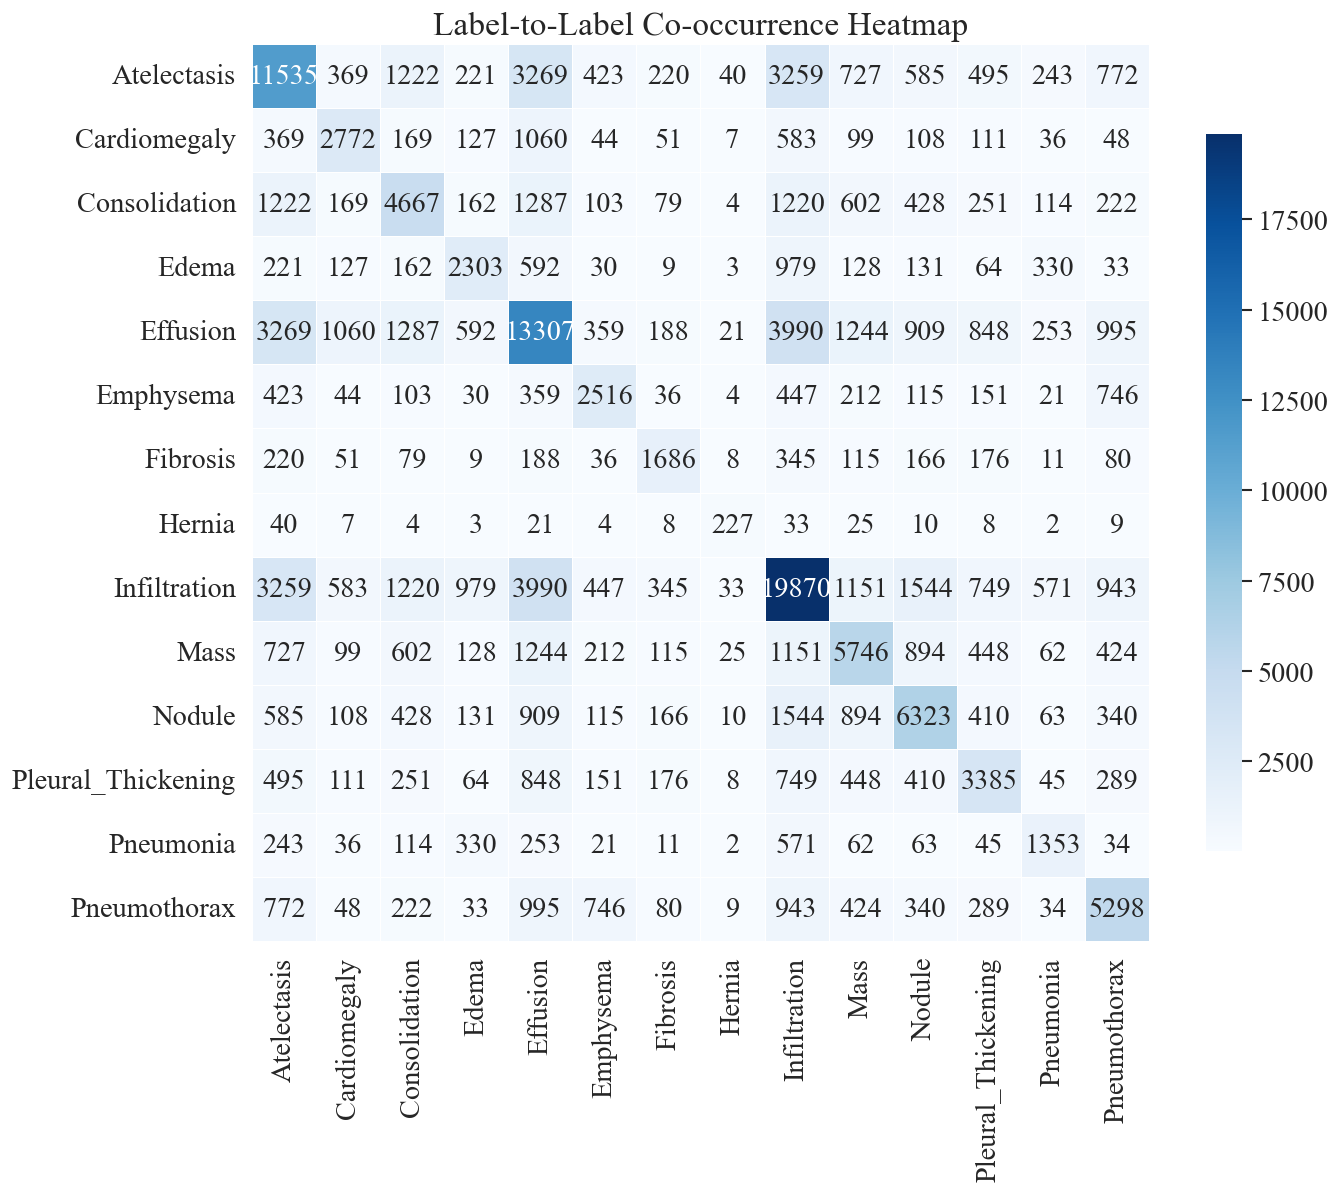

In [66]:
# Advanced analytics: co-occurrence and imbalance diagnostics (excluding 'No Finding' in heatmap)
label_names = [c.replace("label__", "") for c in label_cols]
label_matrix = df[label_cols].astype(int)

co_occurrence = label_matrix.T.dot(label_matrix)
co_occurrence.index = label_names
co_occurrence.columns = label_names

# Jaccard overlap between labels (kept for analysis table if needed)
counts = np.diag(co_occurrence.values)
union = counts[:, None] + counts[None, :] - co_occurrence.values
with np.errstate(divide="ignore", invalid="ignore"):
    jaccard = np.divide(co_occurrence.values, union, where=union != 0)

jaccard_df = pd.DataFrame(jaccard, index=label_names, columns=label_names)

# Imbalance ratio (majority/minority prevalence)
label_counts = label_matrix.sum(axis=0).sort_values(ascending=False)
imbalance_ratio = (label_counts.max() / label_counts[label_counts > 0].min()) if (label_counts > 0).any() else np.nan

print(f"Imbalance ratio (max/min non-zero label count): {imbalance_ratio:.2f}")
print("Top 10 label counts:")
display(label_counts.head(10).to_frame("count"))

# Remove No Finding from co-occurrence heatmap and show integer counts
co_occurrence_plot = co_occurrence.drop(index="No Finding", columns="No Finding", errors="ignore")

plt.figure(figsize=(12, 10))
sns.heatmap(co_occurrence_plot, cmap="Blues", square=True, annot=True, fmt=".0f", linewidths=0.3, cbar_kws={"shrink": 0.8})
plt.title("Label-to-Label Co-occurrence Heatmap")
plt.tight_layout()
plt.show()

## Patient-Level Leakage Risk

**Images per patient distribution:** Most patients in the NIH dataset have between 1 and 3 scans, but a small number of patients (often those with chronic conditions) contribute many more images. The right-skewed histogram, after IQR-based outlier removal, makes the typical patient contribution clearly visible. Outlier patients (>20 images) warrant inspection — they can dominate training and represent edge cases potentially not present in validation splits.

**Simulated leakage rate:** The Monte Carlo simulation assigns images to train/val/test randomly (70/15/15) and measures what fraction of patients appear in more than one split. A leakage rate above ~50 % means the majority of patients have images in multiple partitions — **this is a critical data science flaw**. When the same patient appears in both training and validation, the model can memorize patient-specific anatomy rather than learning generalizable pathology patterns, inflating reported AUC by 2–5 points compared to true held-out performance.

**Correct splitting strategy:** Split should be done **at the patient level**, not the image level:
```python
train_patients, val_patients, test_patients = patient_level_split(all_patient_ids, ratios=[0.7, 0.15, 0.15])
```
This guarantees zero patient leakage and produces evaluation metrics that reliably predict real-world performance on new patients.

--- Image Counts per Patient by Gender ---
        count  mean  median   std  95th_percentile
gender                                            
F       14175  3.44     1.0  6.91             12.0
M       16630  3.81     1.0  7.55             14.0
------------------------------------------


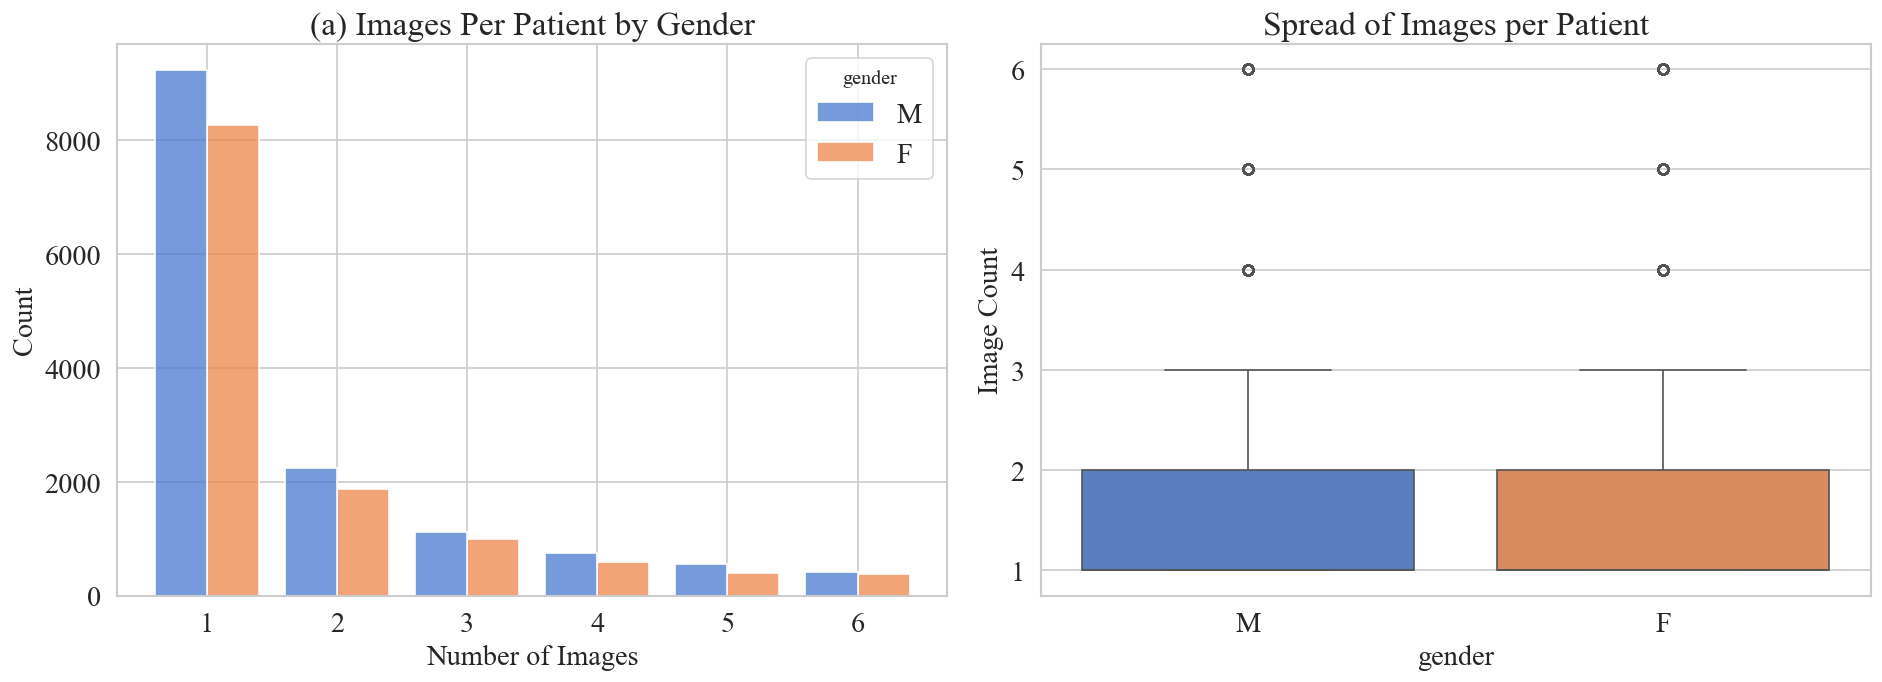

(b) Estimated Patient Leakage (Random Split):
 - Male Patients:   32.61%
 - Female Patients: 29.96%


In [63]:
# 1. Ensure Times New Roman and styling
plt.rcParams.update({'font.family': 'serif', 'font.serif': ['Times New Roman'], 'mathtext.fontset': 'stix'})

if "patient_id" in df.columns and "gender" in df.columns:
    # Group by patient and gender to get image counts per patient
    patient_stats = df.groupby(["patient_id", "gender"])["image_id"].nunique().reset_index(name="image_count")

    # (A) Numerical Summary by Gender
    print("--- Image Counts per Patient by Gender ---")
    summary_by_gender = patient_stats.groupby("gender")["image_count"].agg(['count', 'mean', 'median', 'std'])
    summary_by_gender['95th_percentile'] = patient_stats.groupby("gender")["image_count"].quantile(0.95)
    print(summary_by_gender.round(2))
    print("-" * 42)

    # (B) Remove Outliers for Visualization (Applied per group or globally)
    q1, q3 = patient_stats["image_count"].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    patient_stats_filtered = patient_stats[patient_stats["image_count"] <= upper]

    # (C) Visualization: Distribution Comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Histogram (Comparison)
    sns.histplot(data=patient_stats_filtered, x="image_count", hue="gender", 
                 multiple="dodge", shrink=0.8, bins=np.arange(0.5, upper + 1.5, 1),
                 palette="muted", ax=axes[0])
    axes[0].set_title("(a) Images Per Patient by Gender")
    axes[0].set_xlabel("Number of Images")
    axes[0].set_xticks(range(1, int(upper) + 1))

    # Plot 2: Boxplot (To see the spread clearly)
    sns.boxplot(data=patient_stats_filtered, x="gender", y="image_count", palette="muted", ax=axes[1])
    axes[1].set_title("Spread of Images per Patient")
    axes[1].set_ylabel("Image Count")

    plt.tight_layout()
    plt.show()

    # (D) Leakage Risk Simulation (Gender-Aware)
    rng = np.random.default_rng(RANDOM_STATE)
    sample_df = df[["patient_id", "gender", "image_id"]].dropna().copy()
    
    # We'll track the leakage rate specifically for each gender
    leakage_results = {"M": [], "F": []}

    for _ in range(25):
        split = rng.choice(["train", "val", "test"], size=len(sample_df), p=[0.7, 0.15, 0.15])
        sample_df["split"] = split
        
        # Identify which patients have images in more than one split
        split_diversity = sample_df.groupby(["patient_id", "gender"])["split"].nunique()
        leaked_mask = split_diversity > 1
        
        # Calculate rates per gender
        for gender in ["M", "F"]:
            if gender in leaked_mask.index.get_level_values('gender'):
                rate = leaked_mask.xs(gender, level='gender').mean()
                leakage_results[gender].append(rate)

    print(f"(b) Estimated Patient Leakage (Random Split):")
    print(f" - Male Patients:   {np.mean(leakage_results['M']) * 100:.2f}%")
    print(f" - Female Patients: {np.mean(leakage_results['F']) * 100:.2f}%")

else:
    print("Required columns (patient_id, gender) not found.")